In [34]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [38]:
!pip -q install albumentations iterative-stratification

In [35]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image
from IPython.display import display

# Utils

In [36]:
def annotation_visualize(root_dir, image_name: str) -> None:
    possible_exts = ['.jpg', '.jpeg', '.png']
    
    # Find actual image path
    for ext in possible_exts:
        candidate = os.path.join(root_dir, 'images', image_name + ext) if not image_name.endswith(ext) else os.path.join(root_dir, 'images', image_name)
        if os.path.exists(candidate):
            image_name = image_name + ext
            # print(image_name)
            break

    # Open image, annotation file
    image = Image.open(os.path.join(root_dir, 'images', image_name))
    with open(os.path.join(root_dir, 'annotations', image_name + '.json')) as file:
        file = json.load(file)
    
    annotations = file['Annotations']
    
    # Plotting bounding boxes
    fig, ax = plt.subplots()
    for annotation in annotations:
        # Draw bounding boxes
        bbox = annotation['BoundingBox']
        rect = patches.Rectangle(
            (bbox[0], bbox[1]), # (x, y)
            bbox[2]-bbox[0],    # width
            bbox[3]-bbox[1],    # height
            linewidth=1,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)
        
        # Add classname
        ax.text(
            bbox[0], bbox[1]-5,
            annotation['classname'],
            fontsize=10,
            color='white',
            verticalalignment='bottom',
            bbox=dict(facecolor='red', edgecolor='none')
        )
        
    plt.imshow(image)
    plt.show()
    plt.close()

In [37]:
import shutil

# Splitting images
def copy_and_split(image_dir, train_list, val_list):
    train_dir = os.path.join(image_dir, 'train')
    val_dir = os.path.join(image_dir, 'val')
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)
    root_dir = '/kaggle/input/face-mask-detection-dataset/Medical mask/Medical mask/Medical Mask/images'
    
    for image_name in train_list:
        scr_image = os.path.join(root_dir, image_name)
        dst_image = os.path.join(train_dir, image_name)
        shutil.copy(scr_image, dst_image)

    for image_name in val_list:
        scr_image = os.path.join(root_dir, image_name)
        dst_image = os.path.join(val_dir, image_name)
        shutil.copy(scr_image, dst_image)

In [39]:
# Augumentation to create more instance for imbalance classes
import albumentations as A

def img_aug(annotation_dir, img_dir, rare_cls_img=None):
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.HueSaturationValue(
            hue_shift_limit=5,
            sat_shift_limit=30,
            val_shift_limit=20,
            p=0.5
        ),
        A.Rotate(limit=5, border_mode=0, p=0.5),
    ],
    bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

    annotation_list = os.listdir(annotation_dir)
    aug_index = 0
    for t in range(0, 3):
        for annotation_file in rare_cls_img:
            with open(os.path.join(annotation_dir, annotation_file), 'r') as f:
                clss = []
                bboxs = []
                # aug = False
                for line in f:
                    cls, x_center, y_center, width, height = map(float, line.split())
                    cls = int(cls)

                    clss.append(cls)
                    bboxs.append([x_center, y_center, width, height])
                    
                # if aug:
                for ext in ['.jpg', '.jpeg', '.png']:
                    img_path = os.path.join(img_dir, annotation_file.replace('.txt', ext))
                    if os.path.exists(img_path):
                        break 
            
                img = np.array(Image.open(img_path).convert('RGB'))
                aug_result = transform(image=img, bboxes=bboxs, class_labels=clss)
    
                aug_img = aug_result['image']
                aug_bboxes = aug_result['bboxes']
                aug_labels = aug_result['class_labels']
    
                # Save augmented image
                img_name = f"aug{aug_index}.jpg"
                ann_name = f"aug{aug_index}.txt"
                aug_index += 1
    
                Image.fromarray(aug_img).save(os.path.join(img_dir, img_name))
                with open(os.path.join(annotation_dir, ann_name), 'w') as f_out:
                    for cls, bbox in zip(aug_labels, aug_bboxes):
                        f_out.write(f"{int(cls)} {' '.join(map(str, bbox))}\n")
    print(f"Performed augmentations on {aug_index} images")

In [158]:
from tqdm.notebook import tqdm

# Convert to YOLO format annotations
def json_to_yolo(root_dir, labels_dir, file_list, classlist, val=False):
    if val:
        labels_dir = os.path.join(labels_dir, 'val')
        os.makedirs(labels_dir, exist_ok=True)
    else:
        labels_dir = os.path.join(labels_dir, 'train')
        os.makedirs(labels_dir, exist_ok=True)

    pbar = tqdm(file_list)
    for filename in pbar:
        image_name, ext = os.path.splitext(filename)
        # Get file path
        annotation_dir = os.path.join(root_dir, 'annotations', filename + '.json')
        image_dir = os.path.join(root_dir, 'images', filename)

        with open(annotation_dir, 'r') as file,\
        open(os.path.join(labels_dir, image_name + '.txt'), 'w') as yolo_file:
            json_file = json.load(file)
            
            # Get image size
            image = Image.open(image_dir)
            w, h = image.size
            
            # Get JSON annotations
            annotations = json_file['Annotations']
            for annotation in annotations:
                # Convert to YOLO annotations
                class_id = classlist.index(annotation['classname'])
                bbox = annotation['BoundingBox']
                width = (bbox[2] - bbox[0])/w
                height = (bbox[3] - bbox[1])/h
                
                yolo_file.write(f"{class_id} {(bbox[2] + bbox[0])/2/w} {(bbox[3] + bbox[1])/2/h} {width} {height}\n")
    print("Converted all annotations to YOLO format!")

In [40]:
# img_aug('/kaggle/working/labels/train', '/kaggle/working/images/train', rare_cls_img)

In [151]:
root_dir = '/kaggle/input/face-mask-detection-dataset/Medical mask/Medical mask/Medical Mask'
image_dir = '/kaggle/working/images'
labels_dir = '/kaggle/working/labels/'

classes = ['face_with_mask', 'mask_surgical', 'mask_colorful', 'face_other_covering', 'face_no_mask',
           'eyeglasses', 'hat', 'sunglasses', 'face_with_mask_incorrect', 'hood']
           
undesired_classes = ['face_shield', 'hair_net', 'scarf_bandana', 'goggles', 'helmet', 'hijab_niqab',
                     'balaclava_ski_mask', 'turban', 'gas_mask', 'other']

In [65]:
bad_images = df.loc[df["classname"].isin(undesired_classes), "name"].unique()

df_clean = df[~df["name"].isin(bad_images)]

In [71]:
import numpy as np
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

image_names = df_clean["name"].unique()
classes = sorted(df_clean["classname"].unique())

class_to_idx = {c: i for i, c in enumerate(classes)}

y = np.zeros((len(image_names), len(classes)), dtype=int)

for i, name in enumerate(image_names):
    img_classes = df_clean.loc[df_clean["name"] == name, "classname"].unique()
    for c in img_classes:
        y[i, class_to_idx[c]] = 1

In [75]:
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(msss.split(image_names, y))

train_names = image_names[train_idx]
test_names  = image_names[test_idx]

train_df = df_clean[df_clean["name"].isin(train_names)]
val_df  = df_clean[df_clean["name"].isin(test_names)]

In [215]:
# Splitting image list
train_list = train_df["name"].unique().tolist()
val_list = val_df["name"].unique().tolist()

# # Creating directories yaml file
# annotation_list = os.listdir(os.path.join(root_dir, 'annotations'))

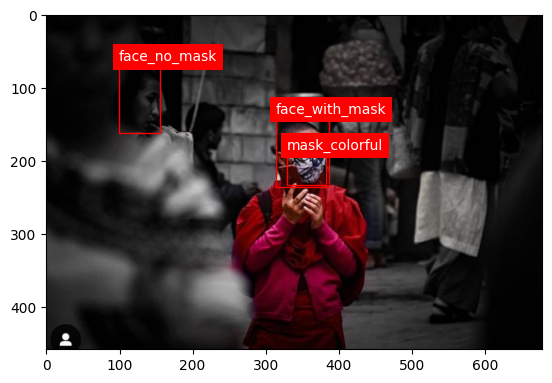

In [205]:
image_name = '2780'
annotation_visualize(root_dir, image_name)

In [206]:
!cat /kaggle/working/labels/train/2780.txt

0 0.5162002945508101 0.4148471615720524 0.10751104565537556 0.20087336244541484
2 0.524300441826215 0.4650655021834061 0.07952871870397643 0.08733624454148471
4 0.187039764359352 0.25436681222707425 0.08247422680412371 0.1943231441048035


In [217]:
# !rm -rf /kaggle/working/labels/train/*
# !rm -rf /kaggle/working/labels/val/*

In [ ]:
# print(len(os.listdir("/kaggle/working/images/train")))
# print(len(os.listdir("/kaggle/working/images/val")))

In [113]:
copy_and_split(image_dir, train_list, val_list)

In [219]:
json_to_yolo(root_dir, labels_dir, train_list, classes)
json_to_yolo(root_dir, labels_dir, val_list, classes, val=True)

  0%|          | 0/2605 [00:00<?, ?it/s]

Converted all annotations to YOLO format!


  0%|          | 0/659 [00:00<?, ?it/s]

Converted all annotations to YOLO format!


In [49]:
def cls_distribution(annotation_dir, classlist):
    annotation_list = os.listdir(annotation_dir)
    classes = [0] * len(classlist)
    for annotation_file in annotation_list:
        with open(os.path.join(annotation_dir, annotation_file), 'r') as f:
            for line in f:
                cls = int(line.split(" ")[0])
                classes[cls] += 1

    fig, ax = plt.subplots()
    bars = ax.barh(classlist, classes, color='skyblue')

    ax.bar_label(bars, fmt='%d', label_type='edge', padding=3)

    ax.set_xlabel('Count')
    ax.set_ylabel('Class')
    ax.set_title('Class Distribution')
    plt.tight_layout()
    plt.show()

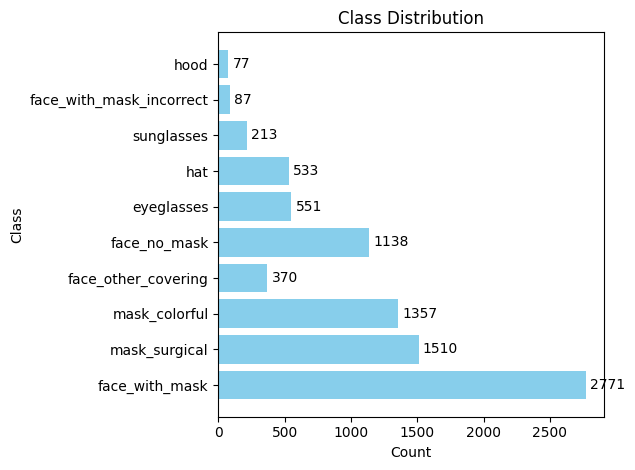

In [227]:
cls_distribution('/kaggle/working/labels/train', classes)

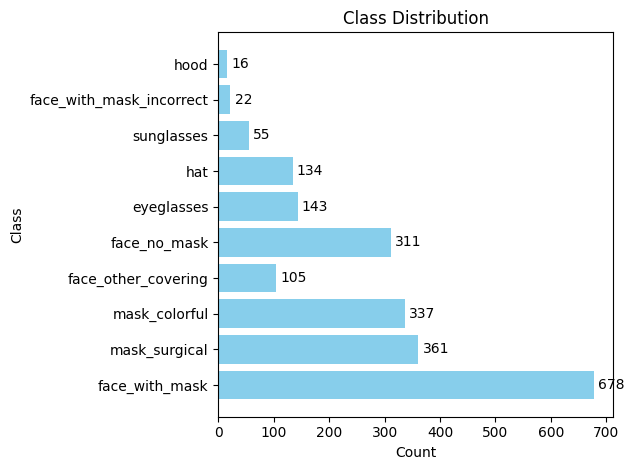

In [222]:
cls_distribution('/kaggle/working/labels/val', classes)

# YOLO Training

In [228]:
# Create yaml file
yaml = """
path: /kaggle/working/
train: images/train
val: images/val

nc: 10
names: ['eyeglasses', 'face_no_mask', 'face_other_covering', 'face_with_mask', 'face_with_mask_incorrect', 
'hat', 'hood', 'mask_colorful', 'mask_surgical', 'sungglasses']
"""
# , 'hair_net', 'scarf_bandana', 'goggles', 'helmet', 
#         'hijab_niqab', 'hood', 'face_shield', 'balaclava_ski_mask', 'face_with_mask_incorrect', 
#         'turban', 'gas_mask', 'other']
with open('dataset.yaml', 'w') as f:
    f.write(yaml)

print("YAML file created!")

YAML file created!


In [54]:
!pip -q install ultralytics

In [229]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

In [230]:
# Train the model
model.train(
    data='dataset.yaml',   # path to your dataset YAML file
    epochs=30,             # number of epochs to train
    imgsz=768,             # image size
    batch=16,              # batch size (adjust based on your GPU)
    device=0,              # GPU device (0 for first GPU, or 'cpu' to train on CPU)
    task='detect',
    mosaic=0.3,
    mixup=0.3,
    cutmix=0.3,
    # resume=True,
)

Ultralytics 8.4.2 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.3, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=train21, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        659       2162      0.797      0.709        0.8      0.557
            eyeglasses        115        143      0.813       0.67      0.741      0.384
          face_no_mask        181        311      0.881      0.906      0.945      0.746
   face_other_covering         78        105      0.783      0.781      0.863      0.636
        face_with_mask        450        678      0.926      0.944       0.97      0.742
face_with_mask_incorrect         20         22      0.479      0.318      0.426      0.303
                   hat        110        134      0.852      0.813      0.902      0.633
                  hood         16         16      0.642      0.375      0.618      0.406
         mask_colorful        271        337      0.878       0.79      0.897      0.682
         mask_surgical        220        361      0.815      0.895      0.889      0.594
           sungglasses         50         55      0.902        0.6      0.747      0.448
Speed: 0.2ms prepro

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a1f32b8e2d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0


image 1/1 /kaggle/input/face-mask-detection-dataset/Medical mask/Medical mask/Medical Mask/images/0109.png: 768x704 1 face_with_mask, 1 mask_surgical, 12.4ms
Speed: 3.2ms preprocess, 12.4ms inference, 1.4ms postprocess per image at shape (1, 3, 768, 704)


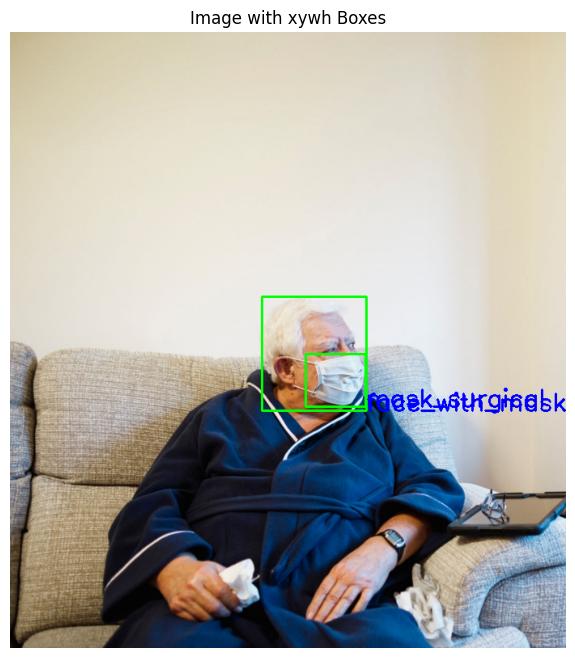

In [242]:
image_name = "0109.png"
result = model.predict(f"/kaggle/input/face-mask-detection-dataset/Medical mask/Medical mask/Medical Mask/images/{image_name}", conf=0.5)
import cv2
import torch

# Sample xywh tensor (center_x, center_y, width, height)

# Load image
image_path = f"/kaggle/input/face-mask-detection-dataset/Medical mask/Medical mask/Medical Mask/images/{image_name}"  # replace with your actual image path
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Image not found at: {image_path}")

# Draw each bounding box
for i, box in enumerate(result[0].boxes.xywh):
    cx, cy, w, h = box.tolist()
    cls = result[0].boxes.cls[i]

    # Convert from center (cx, cy, w, h) to top-left (x1, y1) and bottom-right (x2, y2)
    x1 = int(cx - w / 2)
    y1 = int(cy - h / 2)
    x2 = int(cx + w / 2)
    y2 = int(cy + h / 2)
    # Draw rectangle on the image
    cv2.rectangle(image, (x1, y1), (x2, y2), color=(0, 255, 0), thickness=2)
    cv2.putText(
        image, 
        model.names[int(cls.item())], 
        (x2, y2), 
        cv2.FONT_HERSHEY_SIMPLEX, 
        1, 
        (255, 0, 0), 
        2
    )

# Show the image
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display using matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.axis('off')
plt.title("Image with xywh Boxes")
plt.show()

In [ ]:
# !pip install pipreqs

In [ ]:
# %%writefile /kaggle/working/temp_code.py
# import cv2
# import json
# import torch
# import shutil
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches

# from PIL import Image
# from ultralytics import YOLO
# from tqdm.notebook import tqdm
# from IPython.display import display

In [ ]:
# !pipreqs /kaggle/working --force